In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [95]:
#Reading CSV
df = pd.read_csv(r'raw.csv')
df.head()

,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,...,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?,addicted
0,21,Bachelor Level,Male,4.00,5.00,10,"Mobile, PC",02:00:00,Yes,4,...,Not regular,Non Paid,3,Bore,Excited,Excited to complete level,No,Yes,Yes,1
1,22,Bachelor Level,Male,4.00,5.00,11,PC,01:00:00,Yes,1,...,Not regular,Paid,15,Positive,Excited,Excited to complete level,Yes,No,No,0
2,23,Bachelor Level,Male,3.50,4.50,18,Mobile,03:00:00,Yes,3,...,Not regular,Non Paid,1,Positive,Excited,Excited to complete level,No,Yes,No,0
3,21,Bachelor Level,Male,3.75,4.92,10,Mobile,23:00:00,Yes,1,...,Not regular,Non Paid,1,Positive,Excited,No feeling,No,No,Yes,0
4,21,Bachelor Level,Male,3.50,5.00,15,"Mobile, PC",01:00:00,Yes,2,...,Not regular,Non Paid,8,Positive,Excited,Excited to complete level,No,No,Yes,0


In [96]:
#Here 0 respresnt Non-addicted andd 1 respresent addicted
df['addicted'].value_counts()

addicted
0    728
1    334
Name: count, dtype: int64

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1062 entries, 0 to 1061
Data columns (total 21 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     1062 non-null   int64  
 1   Current educational position?                                         1062 non-null   object 
 2   Gender?                                                               1062 non-null   object 
 3   Your  current CGPA?                                                   1062 non-null   float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  1062 non-null   float64
 5   At what age you had started playing games?                            1062 non-null   int64  
 6   Do you play games on mobile or pc?                                    1062 non-null   object 
 7

In [98]:
df.describe()

,What is your age?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,The average time you spend playing games?,How many time you spend with family and friend?,addicted
count,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000,1062.000000
mean,22.935970,3.178569,8.303493,19.210923,3.707156,3.101695,0.314501
std,3.128966,0.596696,134.338582,3.071064,1.648101,2.076078,0.464536
min,18.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,2.880000,3.832500,18.000000,2.000000,2.000000,0.000000
50%,23.000000,3.070000,4.150000,20.000000,4.000000,3.000000,0.000000
75%,25.000000,3.630000,4.797500,21.000000,5.000000,4.000000,1.000000
max,30.000000,5.000000,4382.000000,24.000000,10.000000,24.000000,1.000000


In [99]:
df['How you fill when you can not play game in whole day?'].value_counts()

How you fill when you can not play game in whole day?
Positive                     297
Upset                        264
Depressed                    245
Angry                        237
Nothing                        5
Calm                           1
Nothing special                1
feel* ???? I feel sleepy.      1
Nothing matter                 1
Doesn't matter                 1
No fillings                    1
Bore                           1
Not Bad                        1
No feeling                     1
Aright                         1
No feelings                    1
Not addicted type              1
Normal                         1
I don't feel anything          1
Name: count, dtype: int64

Data Pre-processing

In [100]:
positive=['Alright', 'Calm', 'Not bad', 'Positive','Not Bad','Nothing ','Aright ']
negative = ['Angry', 'Bore', 'Depressed', 'feel* ???? I feel sleepy. ', 'Upset']
neutral = ["Doesn't matter", "I don't feel anything ", "No feeling ", "No feelings ", "Normal", "Nothing special", "Not addicted type","Not Bad","Nothing ","Nothing"]

In [101]:
for i in range(len(df)):
  if df['Your Higher Secondary School(H. SC) or A level or equivalent result?'][i] == 4382.0:
     df['Your Higher Secondary School(H. SC) or A level or equivalent result?'][i] = 4.32
  if df['How you fill when you can not play game in whole day?'][i] in positive:
    df['How you fill when you can not play game in whole day?'][i] = 'positive'
  elif df['How you fill when you can not play game in whole day?'][i] in negative:
    df['How you fill when you can not play game in whole day?'][i] = 'negative'

  else:
    df['How you fill when you can not play game in whole day?'][i] = 'neutral'

C:\Users\HP\AppData\Local\Temp\ipykernel_1816\1247655970.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['How you fill when you can not play game in whole day?'][i] = 'negative'
C:\Users\HP\AppData\Local\Temp\ipykernel_1816\1247655970

In [102]:
df['How you fill when you can not play game in whole day?'].value_counts()

How you fill when you can not play game in whole day?
negative    747
positive    299
neutral      16
Name: count, dtype: int64

In [103]:
df['When you go to sleep?'] = pd.to_datetime(df['When you go to sleep?'])
df['When you go to sleep?'] = df['When you go to sleep?'].apply(lambda x: x if x.time().hour >= 21 or x.time().hour < 9 else x - pd.Timedelta(hours=12))
df['When you go to sleep?'] = df['When you go to sleep?'].apply(lambda x: x.replace(minute=0, second=0))
df['When you go to sleep?'] = df['When you go to sleep?'].dt.hour

C:\Users\HP\AppData\Local\Temp\ipykernel_1816\3345140537.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['When you go to sleep?'] = pd.to_datetime(df['When you go to sleep?'])


In [104]:
df['Which type of game you addict more?'].unique()

array(['FIFA, PES, Valorant', 'CALL OF DUTY', 'GENSHIN IMPACT', 'CR',
       'FIFA, PUBG, PES, CALL OF DUTY', 'FREE FIRE, PES',
       'FIFA, COC, CALL OF DUTY,', 'FIFA', 'PUBG', 'PES',
       'PUBG, COC, PES, CALL OF DUTY', 'Common',
       'PUBG, COC, CALL OF DUTY', 'PUBG, PES', 'Candy crush',
       'PUBG, Rpg, adventure type game most of', 'FIFA, PUBG, FREE FIRE',
       'No', 'PUBG, COC', 'PUBG, ', 'FIFA, PUBG, COC, CALL OF DUTY',
       'PES, CALL OF DUTY, GTA V, ', 'Chess', 'Cooking fever',
       'FREE FIRE', 'PUBG, FREE FIRE, COC, IGA, CALL OF DUTY',
       'FIFA, CALL OF DUTY', 'FIFA, ', 'PUBG, CALL OF DUTY',
       'CALL OF DUTY, The Walking dead ', 'Nothing', 'Ludo', 'Valorant',
       'Match three puzzle game', 'COC, ', 'FIFA, PUBG, COC, ACE Fighter',
       'FIFA, PUBG, CALL OF DUTY', 'Vice city',
       'FIFA, PUBG, FREE FIRE, COC, PES, CALL OF DUTY, ', 'COC',
       'PUBG, COC, Worm zone', 'PUBG, GTA V', 'Mobile legends',
       'FIFA, PUBG, PES',
       'FIFA, PUBG, FR

In [105]:
df[['first_choice', 'second_choice', 'third_choice']] = df['Which type of game you addict more?'].str.split(',', expand=True).iloc[:,:3]
df[['first_choice', 'second_choice', 'third_choice']] = df[['first_choice', 'second_choice', 'third_choice']].replace({None: np.nan})
df[['first_choice', 'second_choice', 'third_choice']] = df[['first_choice', 'second_choice', 'third_choice']].apply(lambda x: x.str.strip())
counts = df.first_choice.value_counts()
df = df[df['first_choice'].isin(counts[counts >= 4].index)]
df['Which type of game you addict more?'] = df['first_choice']
df.drop(['first_choice', 'second_choice', 'third_choice'],axis = 1, inplace = True)


In [106]:
df['Which type of game you addict more?'].value_counts()
game_map = {
    'PUBG': 'Battle Royale',
    'FREE FIRE': 'Battle Royale',
    'CALL OF DUTY': 'Shooter',
    'IGA': 'Open World',   
    'PES': 'Sports',
    'FIFA': 'Sports',
    'COC': 'Strategy'
}

df['Which type of game you addict more?']= df['Which type of game you addict more?'].map(game_map)



In [107]:
def remove_outliers(df, col_name):
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    filter = (df[col_name] >= Q1 - 1.5 * IQR) & (df[col_name] <= Q3 + 1.5 *IQR)
    return df.loc[filter]

df = remove_outliers(df, 'The average time you spend playing games?')
df = df[df['Your  current CGPA?'] <= 4.5]
df = df[df['Your Higher Secondary School(H. SC) or A level or equivalent result?'] <= 5]

In [108]:
df.head()

,What is your age?,Current educational position?,Gender?,Your current CGPA?,Your Higher Secondary School(H. SC) or A level or equivalent result?,At what age you had started playing games?,Do you play games on mobile or pc?,When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,...,Do you read newspaper?,Which type of game you played most?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,Are you wearing glasses?,addicted
0,21,Bachelor Level,Male,4.00,5.0,10,"Mobile, PC",2,Yes,4,...,Not regular,Non Paid,3,negative,Excited,Excited to complete level,No,Yes,Yes,1
1,22,Bachelor Level,Male,4.00,5.0,11,PC,1,Yes,1,...,Not regular,Paid,15,positive,Excited,Excited to complete level,Yes,No,No,0
4,21,Bachelor Level,Male,3.50,5.0,15,"Mobile, PC",1,Yes,2,...,Not regular,Non Paid,8,positive,Excited,Excited to complete level,No,No,Yes,0
5,21,Bachelor Level,Male,3.00,5.0,11,Mobile,2,No,5,...,Not regular,Paid,1,negative,Excited,Excited to complete level,No,Yes,No,1
6,21,Bachelor Level,Male,3.75,5.0,12,"Mobile, PC",1,Yes,3,...,Not regular,Non Paid,5,negative,Excited,Excited to complete level,No,Yes,Yes,0


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1021 entries, 0 to 1061
Data columns (total 21 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   What is your age?                                                     1021 non-null   int64  
 1   Current educational position?                                         1021 non-null   object 
 2   Gender?                                                               1021 non-null   object 
 3   Your  current CGPA?                                                   1021 non-null   float64
 4   Your Higher Secondary School(H. SC) or A level or equivalent result?  1021 non-null   float64
 5   At what age you had started playing games?                            1021 non-null   int64  
 6   Do you play games on mobile or pc?                                    1021 non-null   object 
 7   Wh

In [110]:
df.drop(columns=['Current educational position?','Are you wearing glasses?','What is your age?','Your  current CGPA?',
                'Your Higher Secondary School(H. SC) or A level or equivalent result?',
                 'At what age you had started playing games?','Do you play games on mobile or pc?','Do you read newspaper?'
                ,'Are you wearing glasses?','Which type of game you played most?','Do you attend your morning class regularly?'
                ],inplace=True,axis=1)

In [111]:
df.head()

,Gender?,When you go to sleep?,The average time you spend playing games?,Which type of game you addict more?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,addicted
0,Male,2,4,Sports,3,negative,Excited,Excited to complete level,No,Yes,1
1,Male,1,1,Shooter,15,positive,Excited,Excited to complete level,Yes,No,0
4,Male,1,2,Sports,8,positive,Excited,Excited to complete level,No,No,0
5,Male,2,5,Battle Royale,1,negative,Excited,Excited to complete level,No,Yes,1
6,Male,1,3,Sports,5,negative,Excited,Excited to complete level,No,Yes,0


In [112]:
df.to_csv('Processed')

In [113]:
YAN = {'Yes':1,'No':0}
Np ={'Not regular':0,'Regular':1}
MF={"Male":0,'Female':1}
BM={'Bachelor Level':0,"Master's Level":1}
pnp={'Non Paid':0,'Paid':1}
EB ={'Excited':0,'Bored':1}
ENS={'Excited to complete level':0,'Stressed':0,'No feeling':1}
npn = {'negative':0,'positive':2,'neutral':1}
EB ={'Excited':0,'Bored':1}
ENS={'Excited to complete level':0,'Stressed':0,'No feeling':1}


In [114]:

df['Do you fill Fatigue?']=df['Do you fill Fatigue?'].map(YAN)
df['Do you play games for stress relief?']=df['Do you play games for stress relief?'].map(YAN)
df['How you fill when you can not play game in whole day?']=df['How you fill when you can not play game in whole day?'].map(npn)
df['How you fill to complete game level?']=df['How you fill to complete game level?'].map(EB)
df['If you didn\'t finish games last level what is your feeling?']=df['If you didn\'t finish games last level what is your feeling?'].map(ENS)
df['Gender?']=df['Gender?'].map(MF)
df=pd.get_dummies(data=df,columns=['Which type of game you addict more?'],dtype='int')


In [115]:
df.head()

,Gender?,When you go to sleep?,The average time you spend playing games?,How many time you spend with family and friend?,How you fill when you can not play game in whole day?,How you fill to complete game level?,If you didn't finish games last level what is your feeling?,Do you fill Fatigue?,Do you play games for stress relief?,addicted,Which type of game you addict more?_Battle Royale,Which type of game you addict more?_Open World,Which type of game you addict more?_Shooter,Which type of game you addict more?_Sports,Which type of game you addict more?_Strategy
0,0,2,4,3,0,0,0,0,1,1,0,0,0,1,0
1,0,1,1,15,2,0,0,1,0,0,0,0,1,0,0
4,0,1,2,8,2,0,0,0,0,0,0,0,0,1,0
5,0,2,5,1,0,0,0,0,1,1,1,0,0,0,0
6,0,1,3,5,0,0,0,0,1,0,0,0,0,1,0


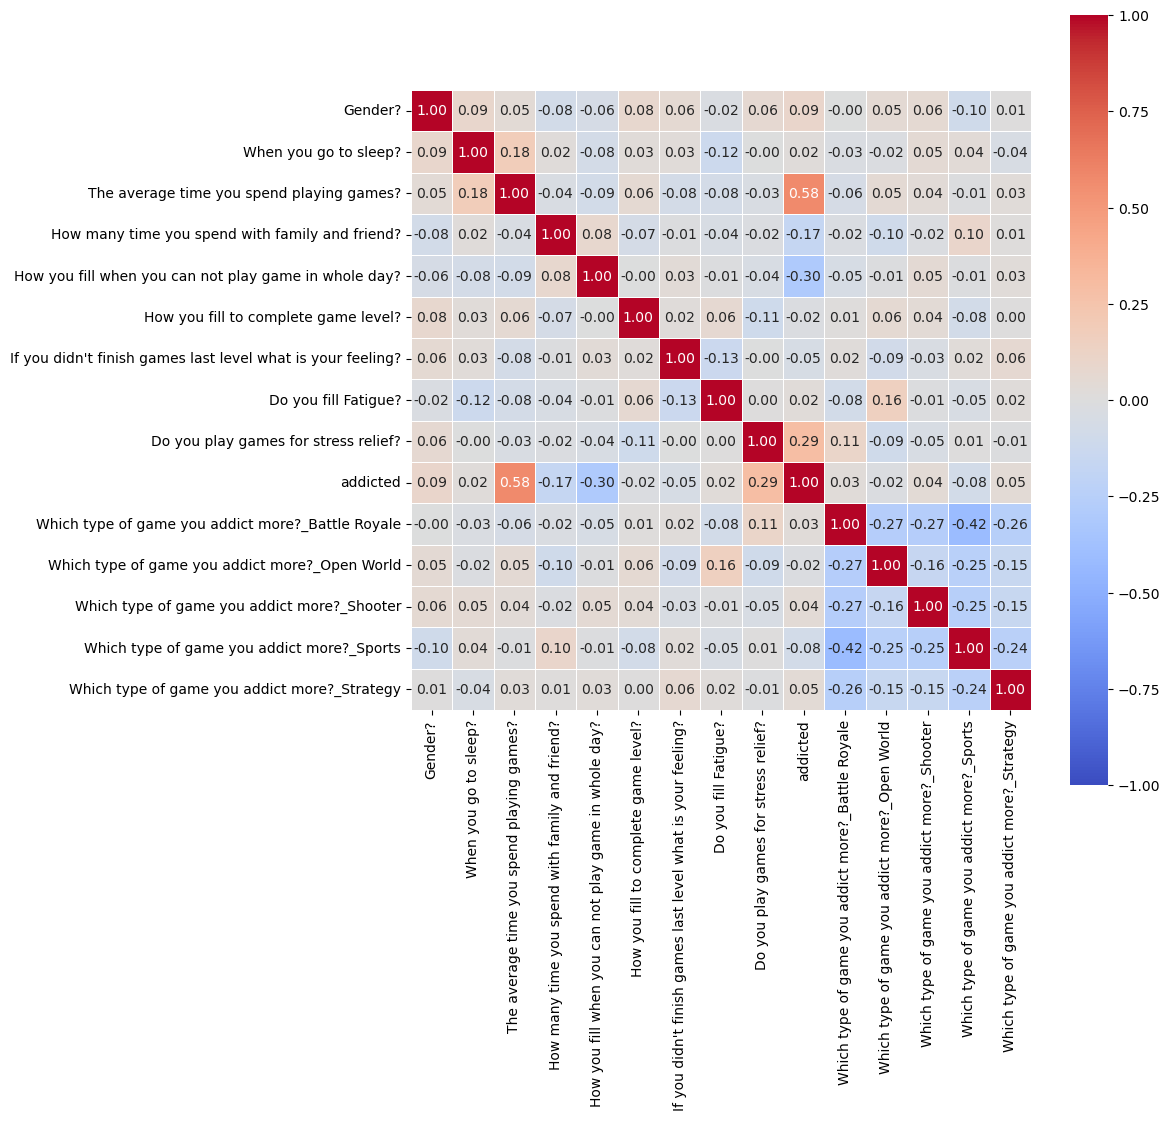

In [116]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(method='spearman'),cmap='coolwarm',fmt='.2f',square=True,annot=True,linewidths=0.5,vmax=1,vmin=-1)
plt.show()